#### Gaussian Bayesian Classifier - Qaus Bayes klassifikatoru və ya Qaus paylanmasına əsaslanan Bayes təsnifatçısı

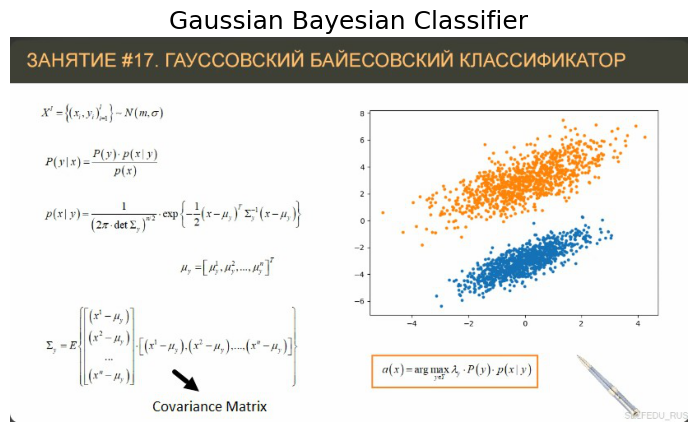

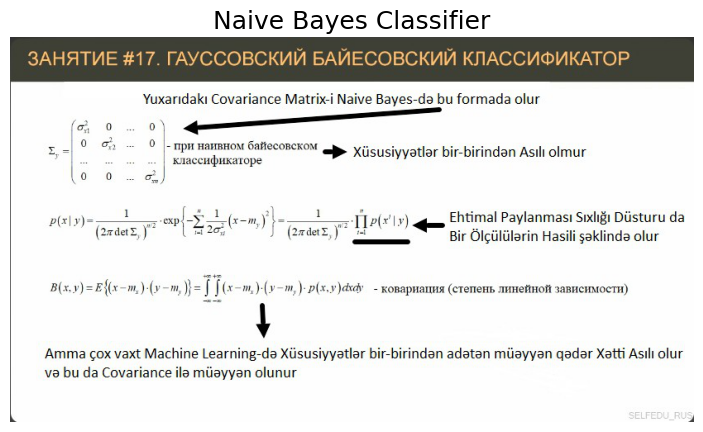

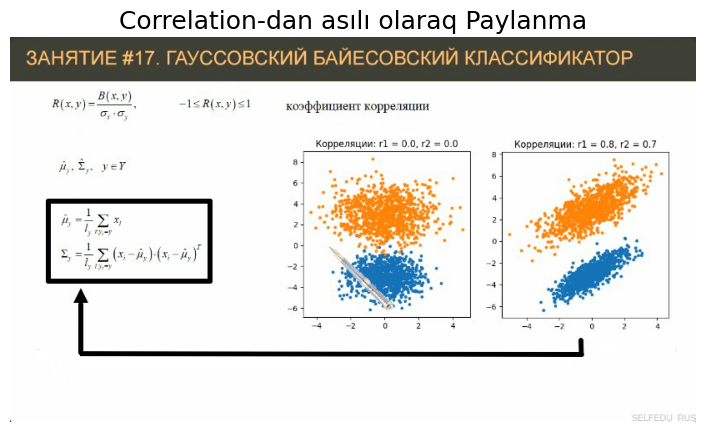

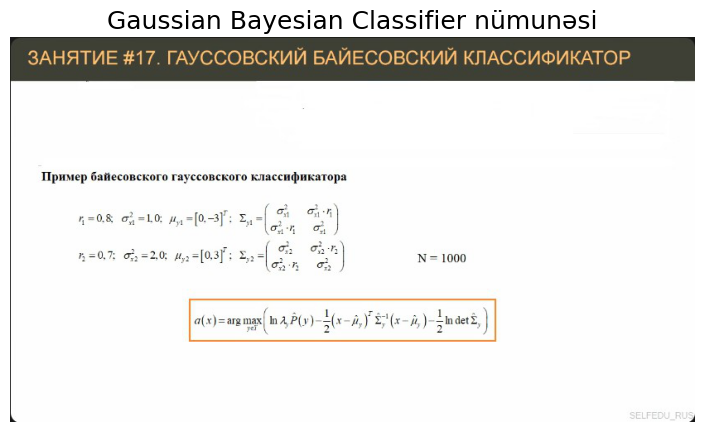

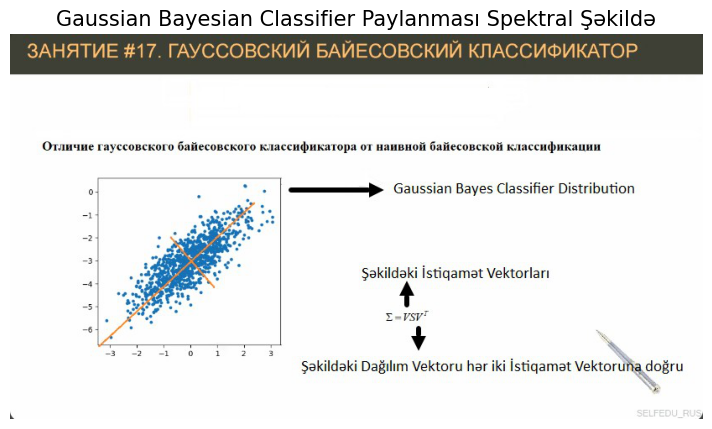

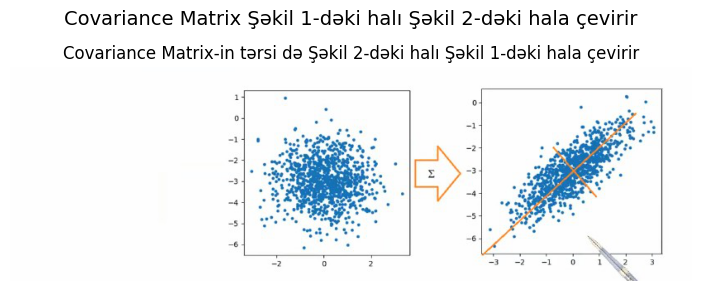

In [1]:
from PIL import Image

# Fayl yolunun əsas hissəsi
base_path = r'C:\Users\dell\Desktop\Selfedu\Pictures\ML_17_'

# Şəkilləri saxlayacağımız siyahı
image_list = []

# 1-dən 5-ə qədər olan şəkilləri dövr ilə açırıq
for i in range(1, 7):  # 1-dən 5-ə qədər
    full_path = f'{base_path}{i}.jpg'  # Fayl yolunu dinamik olaraq yaradırıq
    img = Image.open(full_path)
    image_list.append(img)  # Şəkili siyahıya əlavə edirik

# Nəticə: images siyahısında bütün yüklənmiş şəkillər olacaq

import matplotlib.pyplot as plt

# Şəkilləri göstərin
for i, image in enumerate(image_list):
    if i == 5:
        plt.figure(figsize=(8.8, 4))      
    else:     
        plt.figure(figsize=(25, 5))  # Şəkilin ölçüsü    
        
    if i < 1:
        plt.title("""Gaussian Bayesian Classifier""", size='18')
    elif i < 2:
        plt.title("""Naive Bayes Classifier""", size='18')
    elif i < 3:
        plt.title("""Correlation-dan asılı olaraq Paylanma""", size='18')
    elif i < 4:
        plt.title("""Gaussian Bayesian Classifier nümunəsi""", size='18')
    elif i < 5:
        plt.title("""Gaussian Bayesian Classifier Paylanması Spektral Şəkildə""", size='15')
    elif i < 6:
        plt.text(0.5, 1.2,
         "Covariance Matrix Şəkil 1-dəki halı Şəkil 2-dəki hala çevirir",
         ha='center',
         transform=plt.gca().transAxes,
         fontsize=14)
        
        plt.title("""Covariance Matrix-in tərsi də Şəkil 2-dəki halı Şəkil 1-dəki hala çevirir""", size='12')

    plt.imshow(image)
    plt.axis('off')  # Oxları gizlətmək üçün
    plt.show()

### Naive Bayes və Çoxölçülü Gaussian (ümumi halda)



#### 🔹 Naive Bayes 

* Fərziyyə: **x-lər bir-birindən asılı deyil**
* Yəni:
  $$
  \text{Cov}(x_i, x_j) = 0
  $$
* Deməli **correlation = 0**
* Kovariasiya matrisi **diaqonaldır**

---

#### 🔹 Çoxölçülü Gaussian (ümumi halda)

* Heç bir məcburi fərziyyə yoxdur
* Kovariasiya **0 da ola bilər, 0-dan fərqli də**
* Yəni dəyişənlər **korrelyasiyalı ola bilər**

---

#### 🎯 Ən qısa fərq:

* **Naive Bayes → correlation = 0 (məcburi)**
* **Multivariate Gaussian → correlation istənilən ola bilər**

> Yəni Naive Bayes çoxölçülü Gaussian-ın **xüsusi halıdır** (kovariasiya matrisi diaqonal olan halı).


### Əsas prinsip

> Əgər biz bu kovariasiya matrisinin tərsini (inverse) Bayes klassifikatorunda tətbiq ediriksə, demək, biz nöqtələri yeni bir məkana, yeni koordinat sisteminə keçiririk. Bu yeni koordinat sistemində isə həmin nöqtələr artıq korrelyasiya olunmayıb (yəni müstəqildir). Və burada biz onları adi Naiv Bayes kimi emal edirik – sadəcə cəmləyirik və nəticəni alırıq. Elə bu prinsip üzrə də Gauss Bayes Klassifikatoru işləyir.

Sitatıda deyilir ki, **“kovariasiya matrisinin tərsini (inverse) istifadə edərək yeni koordinat sisteminə keçirik”**. Nə deməkdir bunu anlamaq üçün əvvəlcə **Mahalanobis məsafəsi** və Gauss Bayes-ə baxaq.

---
#### 1️⃣ Problem

Normal Bayes Classifierdə hər sinif üçün:

$$
p(x|y=k) = \frac{1}{(2\pi \cdot \det \Sigma_y)^{n/2}} \exp\Big(-\frac12 (x-\mu_k)^T \Sigma_k^{-1} (x-\mu_k)\Big)
$$

* $x$ → nöqtə
* $\mu_k$ → sinifin mərkəzi
* $\Sigma_k$ → kovariasiya matrisi

Buradakı problem: əgər **sütunlar korrelyasiyalıdırsa**, yəni $x_1, x_2$ bir-biri ilə bağlıdırsa, normal “Euklidian məsafə” düzgün işləmir.

---

#### 2️⃣ Mahalanobis məsafəsi = Yeni koordinat sistemi

$$
(x-\mu)^T \Sigma^{-1} (x-\mu)
$$

* Bu məsafə **kovariasiya matrisini tərs çarparaq** hesablanır
* Riyazi mənası: **nöqtəni yeni koordinat sisteminə çeviririk ki, orada bütün dəyişənlər “uncorrelated” olsun**
* Yəni $x_1, x_2$ artıq bir-birinə bağlı deyil, hamısı müstəqildir

Başqa sözlə:

$$
x_{\text{new}} = L^{-1} (x-\mu) \quad \text{və ya } \Sigma^{-1/2}(x-\mu)
$$

* Burada $L$ → kovariasiya matrisinin Cholesky faktorizasiyası
* Bu transformasiya nöqtələri **“standart, uncorrelated” koordinat sisteminə** gətirir

---

#### 3️⃣ Sonra Bayes tətbiqi

Yeni koordinat sistemində artıq dəyişənlər müstəqildir → Naive Bayes kimi sadəcə “toplama” edə bilərik:

$$
\log p(x|y) = \sum_i \log p(x_i|y)
$$

* Yəni Mahalanobis məsafəsi sayəsində **korrelyasiya problemi aradan qalxır**
* Qalan Bayes hesablaması sadə olur

---

#### 🔹 İntuitiv izah

1. Biz orijinal koordinatda $x_1, x_2$ bağlıdır → məsafə hesablaması qarışıq olur
2. $\Sigma^{-1}$ vururuq → nöqtələri “düzləşdiririk”, dəyişənləri ayrıdır
3. İndi Naive Bayes kimi sadə toplama ilə ehtimalları hesablayırıq




#### Çoxölçülü normal paylanmanın (Multivariate Gaussian distribution) sıxlıq funksiyası

$$
p(x \mid y) =
\frac{1}{(2\pi \cdot \det \Sigma_y)^{n/2}}
\exp\Bigg(
-\frac{1}{2} (x-\mu_y)^T \Sigma_y^{-1} (x-\mu_y)
\Bigg)
$$



#### Bu nə deməkdir?

Bu düstur deyir:

> “Əgər sinif $ y $ üçün məlumatlar normal paylanıbsa, onda $ x $-in ehtimal sıxlığı budur.”

Bu xüsusilə **Gaussian Bayes classifier**-də istifadə olunur.

---

#### Hissə-hissə izah

#### 1️⃣ Ön hissə (normalizasiya)

$$
\frac{1}{(2\pi \cdot \det \Sigma_y)^{n/2}}
$$

Bu hissə funksiyanı düzgün ehtimal sıxlığı edir.

* $ \det \Sigma_y $ → kovariasiya matrisinin determinantı
* Bu yayılmanın “həcmini” göstərir
* n → ölçü sayı

---

#### 2️⃣ Eksponent hissə (əsas hissə)

$$
-\frac{1}{2}(x-\mu_y)^T \Sigma_y^{-1}(x-\mu_y)
$$

Bu hissə məsafəni ölçür.

Amma adi Evklid məsafəsi deyil.

Bu:

> **Mahalanobis məsafəsidir**

$$
d_M^2 = (x-\mu)^T \Sigma^{-1}(x-\mu)
$$

Yəni kovariasiyanı nəzərə alan məsafə.

---

#### İntuisiya

Əgər:

* x ortalamaya yaxındırsa → eksponent 0-a yaxın → ehtimal böyük
* x uzaqdadırsa → eksponent böyük mənfi → ehtimal kiçik

---

#### Sadə müqayisə

1 ölçülü normal paylanma yadındadır:

$$
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
$$

Yuxarıdakı düstur onun çoxölçülü versiyasıdır.

---

#### Nə üçün lazımdır?

Bu istifadə olunur:

* Gaussian Naive Bayes
* Quadratic Discriminant Analysis (QDA)
* Linear Discriminant Analysis (LDA)
* Statistik modelləşdirmə

---

Qısa cümlə ilə:

> Bu düstur deyir ki, kovariasiya və ortanı nəzərə alaraq x nöqtəsinin ehtimalı nə qədərdir.



#### Çoxölçülü normal paylanmanın (Multivariate Gaussian distribution) sıxlıq funksiyası - Detalları

Düstur:

$$
p(x \mid y) =
\frac{1}{(2\pi \cdot \det \Sigma_y)^{n/2}}
\exp\Bigg(
-\frac{1}{2} (x-\mu_y)^T \Sigma_y^{-1} (x-\mu_y)
\Bigg)
$$

---

#### $ p(x \mid y) $

👉 **Şərti ehtimal sıxlığı**
- y sinfi məlumdursa, x-in həmin sinifə görə ehtimalı.

---

#### $ x $

👉 **Xüsusiyyət vektoru (feature vector)**
- Məsələn:
$$
x =
\begin{pmatrix}
x^1 \\
x^2 \\
\vdots \\
x^n \\
\end{pmatrix}
$$
Bu müşahidə etdiyimiz məlumat nöqtəsidir.

---

#### $ y $

👉 **Sinif (class label)**
- Məsələn: spam / not spam, xəstə / sağlam və s.

---

#### $ \mu_y $

👉 **y sinfinin orta vektoru (mean vector)**
- Həmin sinif üçün bütün məlumatların ortası.

---

#### $ \Sigma_y $

👉 **y sinfinin kovariasiya matrisi**
- Dəyişənlərin:

* dispersiyalarını (diaqonalda)
* kovariasiyalarını (diaqonaldan kənarda) göstərir.

---

#### $ \Sigma_y^{-1} $

👉 **Kovariasiya matrisinin tərsi (inverse)**
- Bu Mahalanobis məsafəsini hesablamaq üçün lazımdır.

---

#### $ \det \Sigma_y $

👉 **Determinant**
- Paylanmanın “yayılma həcmini” göstərir.
- Determinant böyükdürsə → paylanma daha geniş yayılıb.

---

#### $ n $

👉 **Ölçü sayı (dimension)**
- X-də neçə xüsusiyyət varsa, o qədər.

---

#### $ (x-\mu_y) $

👉 **Mərkəzləşdirilmiş vektor**
- Nöqtənin ortadan nə qədər uzaqda olduğunu göstərir.

---

#### $ (x-\mu_y)^T \Sigma_y^{-1} (x-\mu_y) $

👉 **Mahalanobis məsafəsinin kvadratı**
- Bu kovariasiya nəzərə alınaraq ölçülən məsafədir.
- Adi Evklid məsafəsindən fərqlidir.

---

#### $ \exp(\cdot) $

👉 **Eksponential funksiya**
- Məsafə artdıqca ehtimal sürətlə azalır.

---

#### Qısa məntiq

* x ortaya yaxındır → məsafə kiçik → ehtimal böyük
* x uzaqdır → məsafə böyük → ehtimal kiçik

---

Ən qısa formada:

> Bu düstur “x nöqtəsi y sinfinin normal paylanmasına nə qədər uyğundur?” sualına cavab verir.



### Covariance Matrix-nin Riyazi tərifi




Şəkildə olan düstur budur:

$$
\Sigma_y
=
\mathbb{E}
\left[
\begin{pmatrix}
x^{1}-\mu_y^{1} \\
x^{2}-\mu_y^{2} \\
\vdots \\
x^{n}-\mu_y^{n}
\end{pmatrix}
\begin{pmatrix}
x^{1}-\mu_y^{1} &
x^{2}-\mu_y^{2} &
\cdots &
x^{n}-\mu_y^{n}
\end{pmatrix}
\right]
$$



> **Niyə (x − μ)-ları bir-birinə vururuq?**

> Çünki biz **birlikdə necə dəyişdiklərini ölçmək** istəyirik.

---

#### 1️⃣ Dispersiya niyə kvadratdır?

Tək dəyişən üçün:

$$
Var(X) = E[(X - \mu)^2]
$$

Niyə kvadrat?

* Müsbət və mənfi yayınmalar bir-birini silməsin deyə
* Böyük yayınma daha böyük cəza alsın deyə

---

#### 2️⃣ Bəs iki dəyişən üçün?

İndi fərz et iki dəyişən var:

$$
X \quad və \quad Y
$$

Əgər biz birlikdə necə dəyişdiklərini ölçmək istəyiriksə, baxırıq:

$$
(X - \mu_X)(Y - \mu_Y)
$$

#### Nə baş verir?

| X yayılması | Y yayılması | Hasili |
| ----------- | ----------- | ------ |
| +           | +           | +      |
| −           | −           | +      |
| +           | −           | −      |
| −           | +           | −      |

Görürsən?

* Eyni istiqamət → müsbət
* Əks istiqamət → mənfi

Bu bizə **xətti əlaqənin istiqamətini** verir.

Sonra bunun gözlənilən qiymətini alırıq:

$$
Cov(X,Y)=E[(X-\mu_X)(Y-\mu_Y)]
$$

---

#### 3️⃣ Bəs vektor halında niyə vururuq?

$$
(x - \mu)(x - \mu)^T
$$

Bu əməliyyat avtomatik olaraq bütün cütlüklər üçün bunu hesablayır:

$$
(x^i - \mu_i)(x^j - \mu_j)
$$

Yəni:

* i = j → dispersiya
* i ≠ j → kovariasiya

---

#### 4️⃣ Əsas intuisiya

Əgər vurmasaydıq:

Sadəcə toplasaq → əlaqə ölçülməz
Sadəcə fərq götürsək → istiqamət bilinməz

**Vurma əməliyyatı birlikdə dəyişməyi ölçür.**

---

Qısa cümlə ilə:

> Kvadrat tək dəyişənin yayılmasını ölçür.

> Hasil iki dəyişənin birlikdə yayılmasını ölçür.

$$
$$

#### Daha geniş izah:
#### Bu, kovariasiya matrisinin riyazi tərifidir.


Yəni:

$$
\Sigma_y = E \Big[ (x - \mu_y)(x - \mu_y)^T \Big]
$$

Şəkildə bu açılmış formada göstərilib.

$$
$$

#### Mənası nədir?

Tutaq ki, sənin **n ölçülü təsadüfi vektorun** var:

$$
x =
\begin{bmatrix}
x^1 \\
x^2 \\
\vdots \\
x^n
\end{bmatrix}
$$

və onun orta qiyməti (mean vektoru):

$$
\mu_y =
\begin{bmatrix}
\mu^1_y \\
\mu^2_y \\
\vdots \\
\mu^n_y
\end{bmatrix}
$$

$$
$$

#### İçəridə nə baş verir?

1️⃣ Əvvəl mərkəzləşdiririk:

$$
(x - \mu_y)
$$

Bu o deməkdir ki, hər dəyişəndən öz ortasını çıxırıq.

2️⃣ Sonra bunu öz transpozuna vururuq:

$$
(x - \mu_y)(x - \mu_y)^T
$$

Bu əməliyyat nəticəsində **n×n ölçülü matris** alınır.

3️⃣ Sonda isə gözlənilən qiymət (E[ ]) alırıq.

$$
$$

#### Nəticədə nə alınır?

Bu matrisin elementləri belədir:

$$
\Sigma_{ij} = Cov(x^i, x^j)
$$

Yəni:

* Diaqonal elementlər → **dispersiya**
* Diaqonaldan kənar elementlər → **kovariasiya**

$$
$$

#### Sadə dildə

Bu düstur deyir:

> “Dəyişənlərin ortadan nə qədər yayınmalarının bir-biri ilə necə əlaqəli olduğunu ölçürəm.”

$$
$$

#### Qısa intuisiya

- Əgər iki dəyişən birlikdə artırsa → kovariasiya müsbət
- Əks istiqamətdə dəyişirsə → kovariasiya mənfi
- Əlaqə yoxdursa → kovariasiya 0



#### Niyə Normal (Gaussian) paylanmada R = 0 olduqda tam müstəqillik olur, amma digər paylanmalarda R = 0 sadəcə xətti əlaqənin olmaması deməkdir?

#### 1️⃣ Əvvəlcə: Korelyasiya nə ölçür?

Korelyasiya əmsalı:

$$
R = \frac{Cov(X,Y)}{\sigma_X \sigma_Y}
$$

Bu nəyi ölçür?

👉 **Yalnız xətti əlaqəni.**
- Yəni “X artanda Y düz xətt üzrə dəyişirmi?”

Amma xətti olmayan əlaqələri görmür.

---

#### 2️⃣ Digər paylanmalarda niyə R=0 müstəqillik demək deyil?

Məsələn:

$$
Y = X^2
$$

və X simmetrik paylanıb (məsələn -1, 0, 1).

Burada:

* X və Y açıq şəkildə asılıdır (Y tam X-dən asılıdır)
* Amma Cov(X,Y) = 0 olur
* Deməli R = 0

Çünki:

* X mənfi və müsbət qiymətlər alır
* X·X² simmetriyaya görə orta sıfır verir
* xətti əlaqə yoxdur
* amma **qeyri-xətti əlaqə var**

Ona görə:

> Ümumi halda R = 0 → sadəcə xətti əlaqə yoxdur

---

#### 3️⃣ Bəs niyə Normal paylanmada fərqlidir?

Əgər (X, Y) birlikdə **ikiölçülü normal paylanıbsa**, onda onların birgə sıxlıq funksiyası tamamilə belə yazılır:

$$
(X,Y) \sim \text{Bivariate Normal}
$$

Bu paylanmada:

👉 Asılılıq yalnız kovarians vasitəsilə yaranır.

Normal paylanmanın çox xüsusi xüsusiyyəti var:

> Əgər Cov(X,Y) = 0-dırsa, onda X və Y müstəqildir.

Bu xüsusiyyət **yalnız normal paylanmaya məxsusdur**.

---

#### 4️⃣ Niyə yalnız normal paylanmada belədir?

Çünki:

Normal paylanmada:

* bütün asılılıq strukturu yalnız 1-ci və 2-ci momentlərlə (orta və kovarians) müəyyən olunur
* əlavə gizli qeyri-xətti asılılıq ola bilmir

Digər paylanmalarda isə:

* yüksək dərəcəli momentlər də asılılıq yarada bilər
* kovarians 0 olsa da, daha mürəkkəb əlaqə qalır

---

#### 5️⃣ Qısa müqayisə

| **Paylanma**              | **R = 0 nə deməkdir?** |
| --------------------- | ------------------ |
| **Ümumi paylanma**        | **Xətti əlaqə yoxdur** |
| **Birgə normal paylanma** | **Tam müstəqillik**    |

---

#### 6️⃣ Əsas səbəb bir cümlə ilə

Normal paylanma elə qurulub ki,
**asılılıq yalnız kovariansla ifadə olunur.**

Digər paylanmalarda isə asılılıq kovariansdan kənar formada da mövcud ola bilər.



#### Niyə Normal (Gaussian) paylanmada R = 0 olduqda tam müstəqillik olur, amma digər paylanmalarda R = 0 sadəcə xətti əlaqənin olmaması deməkdir? - Riyazi + İntuitiv + ML baxımından


#### 🔵 1️⃣ Riyazi izah (niyə Normal-da R=0 → müstəqillik?)

Tutaq ki:

$$
(X,Y) \sim \text{Bivariate Normal}
$$

Birgə sıxlıq funksiyası belədir:

$$
f(x,y)= \frac{1}{2\pi\sigma_X\sigma_Y\sqrt{1-\rho^2}}
\exp\left(
-\frac{1}{2(1-\rho^2)}
\left[
\frac{(x-\mu_X)^2}{\sigma_X^2}
-2\rho\frac{(x-\mu_X)(y-\mu_Y)}{\sigma_X\sigma_Y}
+\frac{(y-\mu_Y)^2}{\sigma_Y^2}
\right]
\right)
$$

Burada:

* ρ = korelyasiya
* diqqət et: ortada **-2ρ(...)** termini var

---

#### 🔴 Əgər ρ = 0 olsa:

Ortadakı qarışıq termin yox olur.

Funksiya belə ayrılır:

$$
f(x,y) = f_X(x) \cdot f_Y(y)
$$

Yəni:

Birgə sıxlıq = kənar sıxlıqların hasili

Bu isə müstəqilliyin rəsmi tərifidir.

👉 Deməli Normal paylanmada
$$
\rho = 0 \Rightarrow \text{müstəqillik}
$$

---

#### 🔵 2️⃣ Digər paylanmada niyə alınmır?

Məsələn:

$$
Y = X^2
$$

və X ~ Uniform(-1,1)

Burada:

* Y tam X-dən asılıdır
* amma Cov(X,Y)=0

Çünki:

$$
Cov(X,X^2)=E[X^3]-E[X]E[X^2]
$$

Simmetriyaya görə:

$$
E[X^3]=0
$$

amma asılılıq mövcuddur.

Çünki əlaqə xətti deyil, kvadratdır.

---

#### 🔵 3️⃣ Intuitiv izah

Normal paylanma nədir?

- 🔹 Ellips formalı sıxlıq səthidir
- 🔹 Asılılıq yalnız ellipsin fırlanma bucağı ilə ifadə olunur

Əgər ρ=0 olsa:

Ellips oxlara paralel olur.

Bu o deməkdir ki:

* X dəyişəndə Y sistemli dəyişmir
* əlaqə yoxdur
* paylanma tam ayrılır

Digər paylanmalarda isə forma ellips deyil.

Ona görə kovarians sıfır olsa belə gizli struktur qala bilər.

---

#### 🔵 4️⃣ Machine Learning baxımından

#### 📌 Linear Regression

Model:

$$
Y = wX + b
$$

Əgər Cov(X,Y)=0 olsa:

$$
w = 0
$$

Yəni model xətti əlaqə tapmır.

Amma bu o demək deyil ki əlaqə yoxdur.

Məsələn:

$$
Y = X^2
$$

Linear regression deyəcək:

> əlaqə yoxdur

amma real əlaqə var.

---

#### 🔵 5️⃣ Çox vacib konsept

Normal paylanma:

* yalnız 1-ci və 2-ci momentlərlə tam müəyyən olunur
* kovarians bütün asılılığı idarə edir

Digər paylanmalar:

* yüksək momentlər (3-cü, 4-cü və s.) də rol oynayır
* ona görə kovarians kifayət etmir

---

#### 🔵 6️⃣ Ən qısa nəticə

Ümumi halda:

$$
R=0 \Rightarrow \text{xətti əlaqə yoxdur}
$$

Amma:

$$
(X,Y) \text{ birgə normaldırsa} \Rightarrow R=0 \Rightarrow \text{tam müstəqillik}
$$



### Gaussian Bayes Classifier əsas düsturları:
#### 1️⃣ Gaussian ehtimal sıxlığı funksiyası (likelihood)
#### 2️⃣ Posterior ehtimalı maximallaşdırmaq üçün (Bayes qərarı)
#### 3️⃣ Log-space formulu $α(x)$ - Model Classification



#### 1️⃣ Gaussian ehtimal sıxlığı funksiyası (likelihood)

$$
p(x \mid y) = \frac{1}{(2\pi \cdot \det \Sigma_y)^{n/2}} \exp\Big(-\frac{1}{2} (x - \mu_y)^T \Sigma_y^{-1} (x - \mu_y)\Big)
$$

**İzahı:**

* Bu düstur $x$ vektorunun $y$ sinifinə aid olma ehtimalını göstərir (likelihood).
* Burada:

  * $\mu_y$ → sinif $y$-nin orta vektoru
  * $\Sigma_y$ → sinif $y$-nin kovariasiya matrisi
  * $n$ → xüsusiyyətlərin sayı
* Bu düstur **multivariate normal distribution**-dan alınır.

---

#### 2️⃣ Posterior ehtimalı maximallaşdırmaq üçün (Bayes qərarı)

$$
a(x) = \arg\max_{y \in Y} P(y) \cdot p(x \mid y)
$$

**İzahı:**

* $a(x)$ → Bayes Classifier tərəfindən verilən **proqnozlaşdırılan sinif**
* Bayes teoreminə əsaslanır: $P(y \mid x) \propto P(y) \cdot p(x \mid y)$
* Burada:

  * $P(y)$ → sinifin prior ehtimalı
  * $p(x \mid y)$ → likelihood (yuxarıdakı Gaussian formula)
* Bu düstur **maksimum a posteriori (MAP) qərar qaydasıdır**.

---

#### 3️⃣ Log-space formulu $α(x)$

$$
Model Classification
$$

$$
\alpha(x) = \arg\max_{y \in T} \Big( \ln \hat{P}(y) - \frac{1}{2} (x - \hat{\mu}_j)^T \hat{\Sigma}_j^{-1} (x - \hat{\mu}_j) - \frac{1}{2} \ln \det \hat{\Sigma}_j \Big)
$$

**İzahı:**

* Bu, **log-transform edilmiş** versiondur.
* Multiplikasiya əvəzinə toplama ilə işləyir (rəqəmlərlə daha stabil olur).
* Burada:

  * $\hat{P}(y)$, $\hat{\mu}_j$, $\hat{\Sigma}_j$ → təlim datasından **təxmin edilən** prior, orta və kovariasiya
  * $\ln \det \hat{\Sigma}_j$ → normalizasiya faktoru log-düzənlənmiş formada
* Bu düstur **praktikada Gaussian Bayes Classifier-in implementasiyasında** istifadə olunur.

---

✅ **Xülasə:**

| Düstur                                                                                                                                              | Mənbə / Haradan alınıb                          |
| --------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------- |
| $$p(x \mid y) = \frac{1}{(2\pi \cdot \det \Sigma_y)^{n/2}} \exp(-\frac12 (x-\mu_y)^T \Sigma_y^{-1} (x-\mu_y))$$                                      | Multivariate Gaussian likelihood                |
| $$a(x) = \arg\max_{y \in Y} P(y) \cdot p(x \mid y)$$                                                                                                  | Bayes qərar qaydası (posterior maximallaşdırma) |
| $$\alpha(x) = \arg\max_{y \in T} (\ln \hat{P}(y) - \frac12 (x-\hat{\mu}_j)^T \hat{\Sigma}_j^{-1} (x-\hat{\mu}_j) - \frac12 \ln \det \hat{\Sigma}_j)$$ | Log-space praktik implementasiya (MAP qərarı)   |




### Python dilində - Gaussian Bayesian Classifier Nümunəsi

#### Düsturlar

$$
r_1 = 0.8, \quad \sigma_{x1}^2 = 1.0, \quad \mu_{y_1} = [0, \ -3]^T, \quad
\Sigma_{y_1} =
\begin{pmatrix}
\sigma_{x1}^2 & \sigma_{x1}^2 \cdot r_1 \\
\sigma_{x1}^2 \cdot r_1 & \sigma_{x1}^2
\end{pmatrix}
$$

$$
r_2 = 0.7, \quad \sigma_{x2}^2 = 2.0, \quad \mu_{y_2} = [0, \ 3]^T, \quad
\Sigma_{y_2} =
\begin{pmatrix}
\sigma_{x2}^2 & \sigma_{x2}^2 \cdot r_2 \\
\sigma_{x2}^2 \cdot r_2 & \sigma_{x2}^2
\end{pmatrix}
$$

$$
N = 1000
$$

$$
a(x) = \arg \max_{y \in Y}
\left(
\ln \lambda_y P(y) - \frac{1}{2} (x - \hat{\mu}_y)^T \Sigma_y^{-1} (x - \hat{\mu}_y) - \frac{1}{2} \ln \det \Sigma_y \right)
$$


0


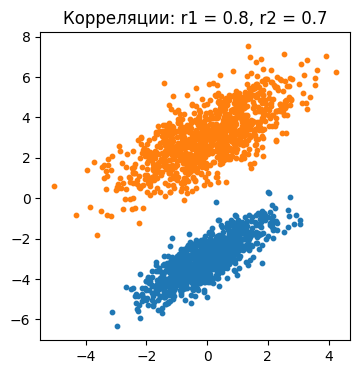

In [2]:
# Numpy kitabxanasını riyazi və matris əməliyyatları üçün idxal edirik.
import numpy as np
# Qrafik çəkmək üçün matplotlib kitabxanasını idxal edirik.
import matplotlib.pyplot as plt

# Nəticələrin hər dəfə eyni alınması üçün random seed təyin edirik.
np.random.seed(1)

# 1-ci sinif üçün korrelyasiya əmsalını təyin edirik.
r1 = 0.8
# 1-ci sinif üçün dispersiyanı (variance) təyin edirik.
D1 = 1.0
# 1-ci sinif üçün orta vektoru (mean) təyin edirik.
mean1 = [0, -3]
# 1-ci sinif üçün kovariasiya matrisini qururuq.
V1 = [[D1, D1 * r1], [D1 * r1, D1]]

# 2-ci sinif üçün korrelyasiya əmsalını təyin edirik.
r2 = 0.7
# 2-ci sinif üçün dispersiyanı təyin edirik.
D2 = 2.0
# 2-ci sinif üçün orta vektoru təyin edirik.
mean2 = [0, 3]
# 2-ci sinif üçün kovariasiya matrisini qururuq.
V2 = [[D2, D2 * r2], [D2 * r2, D2]]

# Hər sinif üçün generasiya ediləcək nümunə sayını təyin edirik.
N = 1000
# 1-ci sinif üçün çoxölçülü normal paylanmadan N ədəd nümunə generasiya edirik və transpoz edirik.
x1 = np.random.multivariate_normal(mean1, V1, N).T
# 2-ci sinif üçün çoxölçülü normal paylanmadan N ədəd nümunə generasiya edirik və transpoz edirik.
x2 = np.random.multivariate_normal(mean2, V2, N).T

# 1-ci sinif üçün sample mean (empirik orta) hesablayırıq.
mm1 = np.mean(x1.T, axis=0)
# 2-ci sinif üçün sample mean hesablayırıq.
mm2 = np.mean(x2.T, axis=0)

# 1-ci sinif datasını mərkəzləşdiririk (hər nöqtədən ortanı çıxırıq).
a = (x1.T - mm1).T
# 1-ci sinif üçün kovariasiya matrisini dot product vasitəsilə əl ilə hesablayırıq.
VV1 = np.array([[np.dot(a[0], a[0]) / N, np.dot(a[0], a[1]) / N],
                [np.dot(a[1], a[0]) / N, np.dot(a[1], a[1]) / N]])

# 2-ci sinif datasını mərkəzləşdiririk.
a = (x2.T - mm2).T
# 2-ci sinif üçün kovariasiya matrisini əl ilə hesablayırıq.
VV2 = np.array([[np.dot(a[0], a[0]) / N, np.dot(a[0], a[1]) / N],
                [np.dot(a[1], a[0]) / N, np.dot(a[1], a[1]) / N]])

# 1-ci sinifin prior ehtimalını və səhv klassifikasiya cəzasını təyin edirik.
Py1, L1 = 0.5, 1
# 2-ci sinifin prior ehtimalını və səhv klassifikasiya cəzasını təyin edirik.
Py2, L2 = 1 - Py1, 1

# Gaussian diskriminant funksiyasını (log formda Bayes qərar funksiyası) təyin edirik.
b = lambda x, v, m, l, py: np.log(l * py) \
                          - 0.5 * (x - m) @ np.linalg.inv(v) @ (x - m).T \
                          - 0.5 * np.log(np.linalg.det(v))

# Klassifikasiya ediləcək giriş vektorunu təyin edirik.
x = np.array([0, -4])
# Hər iki sinif üçün diskriminant funksiyanı hesablayıb maksimum olan sinifi seçirik.
a = np.argmax([b(x, VV1, mm1, L1, Py1),
               b(x, VV2, mm2, L2, Py2)])
# Seçilmiş sinif indeksini ekrana çap edirik.
print(a)

# Qrafik üçün fiqurun ölçüsünü təyin edirik.
plt.figure(figsize=(4, 4))
# Qrafikin başlığını və korrelyasiya dəyərlərini göstəririk.
plt.title(f"Корреляции: r1 = {r1}, r2 = {r2}")
# 1-ci sinif nöqtələrini scatter plot kimi çəkirik.
plt.scatter(x1[0], x1[1], s=10)
# 2-ci sinif nöqtələrini scatter plot kimi çəkirik.
plt.scatter(x2[0], x2[1], s=10)
# Qrafiki ekranda göstəririk.
plt.show()

#### Qısa Məğzinin izahı

#### Nə etdik?

1️⃣ **İki ədəd 2D normal paylanmış sinif yaratdıq**
Yəni iki “bulud” data düzəltdik (iki fərqli qrup).

2️⃣ **Onların real parametrlərini verdik**

* `mean` → mərkəz
* `covariance` → yayılma və dəyişənlər arasındakı əlaqə

3️⃣ **Random nümunələr generasiya etdik**
- Sanki real həyatdan ölçü götürdük və dataset yaratdıq.

4️⃣ **Sample mean və sample covariance hesabladıq**
- Yəni:

> Real parametrləri bilmirmişik kimi davranıb
> Datadan onları “öyrəndik”

5️⃣ **Bayes qərar funksiyası qurduq**
Hər nöqtə üçün bu sualı cavabladıq:

> Bu nöqtə hansı sinifdən gəlmə ehtimalı daha böyükdür?

Burada:

* Mahalanobis məsafəsi → nöqtə mərkəzə nə qədər uyğundur?
* determinant → yayılma nə qədərdir?
* prior → əvvəlcədən hansı sinif daha ehtimallıdır?

6️⃣ **Yeni nöqtəni klassifikasiya etdik**
- Hansının log-ehtimalı böyükdür → o sinif seçildi.

---

#### Məğz nədir?

Biz süni data yaradıb:

* Parametrləri datadan necə öyrənməyi
* Bayes qaydası ilə necə qərar verməyi
* QDA ilə sərhədin necə qurulduğunu

praktik şəkildə göstərdik.

- Əgər kovariasiyalar fərqlidirsə → **QDA** (əyri sərhəd)
- Əgər eyni olsaydı → **LDA** (düz xətt sərhəd)

---

Bir cümləlik xülasə:

> Normal paylanmış iki sinif üçün Bayes optimal klassifikatorunu qurduq və yeni nöqtənin hansı sinfə aid olduğunu ehtimal əsasında tapdıq.



#### Daha geniş İzah:

#### 1️⃣ Biz iki “bulud” yaratdıq → iki sinif, hər biri 2D-də normal paylanmış.

```python
mean1 = [0, -3]
V1 = [[D1, D1 * r1], [D1 * r1, D1]]

mean2 = [0, 3]
V2 = [[D2, D2 * r2], [D2 * r2, D2]]
```

---

#### 2️⃣ Hər bulud üçün **mean (orta)** və **kovariasiya (yayılma və əlaqə)** təyin etdik.

```python
# Bu mərhələ birbaşa yuxarıdakı mean və V1, V2 ilə təyin olunub
# Mean → sinif mərkəzi
# V1, V2 → kovariasiya (yayılma və əlaqə)
```

---

#### 3️⃣ Sonra həmin buludlardan **random nümunələr** generasiya etdik (sanki təbiətdən data topladıq).

```python
x1 = np.random.multivariate_normal(mean1, V1, N).T
x2 = np.random.multivariate_normal(mean2, V2, N).T
```

---

#### 4️⃣ Hər sinif üçün **sample mean və sample covariance** hesabladıq → parametrləri öyrəndik.

```python
mm1 = np.mean(x1.T, axis=0)
mm2 = np.mean(x2.T, axis=0)

a = (x1.T - mm1).T
VV1 = np.array([[np.dot(a[0], a[0]) / N, np.dot(a[0], a[1]) / N],
                [np.dot(a[1], a[0]) / N, np.dot(a[1], a[1]) / N]])

a = (x2.T - mm2).T
VV2 = np.array([[np.dot(a[0], a[0]) / N, np.dot(a[0], a[1]) / N],
                [np.dot(a[1], a[0]) / N, np.dot(a[1], a[1]) / N]])
```

---

#### 5️⃣ **Bayes qərar funksiyası** yaratdıq → Mahalanobis məsafəsi + prior → hər nöqtənin ehtimalını ölçdük.

```python
Py1, L1 = 0.5, 1
Py2, L2 = 1 - Py1, 1

b = lambda x, v, m, l, py: np.log(l * py) \
                          - 0.5 * (x - m) @ np.linalg.inv(v) @ (x - m).T \
                          - 0.5 * np.log(np.linalg.det(v))
```

---

#### 6️⃣ Yeni nöqtəyə baxdıq → hansı sinifin ehtimalı böyükdürsə onu seçdik.

```python
x = np.array([0, -4])
a = np.argmax([b(x, VV1, mm1, L1, Py1),
               b(x, VV2, mm2, L2, Py2)])
print(a)
```

---

#### 7️⃣ Əgər kovariasiya fərqlidirsə → **QDA** olur, əyri sərhəd. Əgər eyni olsaydı → **LDA**, düz xətt sərhəd.

```python
# Vizualizasiya üçün:
plt.figure(figsize=(4, 4))
plt.title(f"Корреляции: r1 = {r1}, r2 = {r2}")
plt.scatter(x1[0], x1[1], s=10)
plt.scatter(x2[0], x2[1], s=10)
plt.show()
```